In [ ]:
!pip install evaluate
!pip install sacrebleu rouge-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.3 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=1f5282aec23ed3b756ab993cf4d0a4ba8043af4547ed569fefddbf0fe4d4f194
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [ ]:
import re, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import GPT2LMHeadModel, GPT2Tokenizer

import evaluate
import re

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings('ignore')

Mounted at /content/drive


In [ ]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Устройство: {DEVICE.upper()}')

MODEL_DIR    = Path('/content/drive/MyDrive/Colab Notebooks/ReviewGeneration/model')
METADATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/ReviewGeneration/model')

Устройство: CPU


In [ ]:
print('Загружаем модель...')
tokenizer = GPT2Tokenizer.from_pretrained(str(MODEL_DIR))
model     = GPT2LMHeadModel.from_pretrained(str(MODEL_DIR))
model     = model.to(DEVICE)
model.eval()
print(f'Модель загружена ({sum(p.numel() for p in model.parameters()):,} параметров)')

with open(METADATA_DIR / 'metadata.json', encoding='utf-8') as f:
    metadata = json.load(f)

BOS_PROMPT = metadata['bos_prompt']
BOS_REVIEW = metadata['bos_review']
EOS_TOKEN  = metadata['eos_token']

with open(MODEL_DIR / 'gen_config.json') as f:
    gen_cfg = json.load(f)

print(f'\nДоступные страны ({len(metadata["unique_countries"])}): {metadata["unique_countries"][:10]}...')
print(f'Диапазон рейтингов: {metadata["rating_range"]}')
print(f'Тем в датасете: {len(metadata["unique_topics"])}')


Загружаем модель...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Модель загружена (81,914,880 параметров)

Доступные страны (144): ['AD', 'AE', 'AF', 'AG', 'AM', 'AR', 'AT', 'AU', 'AZ', 'BA']...
Диапазон рейтингов: [1, 5]
Тем в датасете: 18483


In [ ]:
def generate_review(rating, country, topic, model, tokenizer, gen_cfg, device='cpu'):
    prompt = (
        f"{BOS_PROMPT} "
        f"RATING:{rating} "
        f"COUNTRY:{country} "
        f"TOPIC:{topic} "
        f"{BOS_REVIEW} "
    )

    inputs = tokenizer(prompt, return_tensors='pt').to(device)
    model.eval()

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            **gen_cfg
        )

    full_text = tokenizer.decode(output_ids[0], skip_special_tokens=False)

    if BOS_REVIEW in full_text:
        review = full_text.split(BOS_REVIEW)[-1].strip()
    else:
        review = full_text.strip()

    match = re.search(r'<\s*\/??\s*end\s*of\s*text\s*>', review, flags=re.IGNORECASE)
    if match:
        review = review[:match.start()].strip()

    return review.rstrip('| ').strip()


print('Функция generate_review готова')

Функция generate_review готова


In [ ]:
test_df = pd.read_csv(METADATA_DIR / 'test_split.csv')
print(f'Тестовых примеров: {len(test_df):,}')

N_EVAL = min(100, len(test_df))
eval_df = test_df.sample(N_EVAL, random_state=42).reset_index(drop=True)
print(f'Оцениваем на {N_EVAL} примерах (из {len(test_df)})')

Тестовых примеров: 2,009
Оцениваем на 100 примерах (из 2009)


In [ ]:
def compute_perplexity(texts, model, tokenizer, max_length=256, device='cpu'):
    model.eval()
    total_loss = 0.0
    total_count = 0

    for text in tqdm(texts, desc='Perplexity'):
        enc = tokenizer(
            text,
            return_tensors='pt',
            max_length=max_length,
            truncation=True,
        ).to(device)
        input_ids = enc['input_ids']

        with torch.no_grad():
            outputs = model(input_ids, labels=input_ids)
        total_loss  += outputs.loss.item() * input_ids.shape[1]
        total_count += input_ids.shape[1]

    avg_loss   = total_loss / total_count
    perplexity = np.exp(avg_loss)
    return perplexity


ppl = compute_perplexity(
    eval_df['training_text'].tolist(), model, tokenizer, device=DEVICE
)
print(f'\nPerplexity на тесте: {ppl:.2f}')

Perplexity:   0%|          | 0/100 [00:00<?, ?it/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.



Perplexity на тесте: 18.47


In [ ]:
print(eval_df.columns)

Index(['Reviewer Name', 'Country', 'Rating', 'Review Title', 'Review Text',
       'rating_int', 'text_len', 'topic', 'clean_text', 'country',
       'training_text'],
      dtype='object')


In [ ]:
bleu_metric  = evaluate.load('sacrebleu')
rouge_metric = evaluate.load('rouge')

predictions = []
references  = []

for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc='Генерация для метрик'):
    pred = generate_review(
        rating    = int(row['rating_int']),
        country   = str(row['country']),
        topic     = str(row['topic']),
        model     = model,
        tokenizer = tokenizer,
        gen_cfg   = gen_cfg,
        device    = DEVICE
    )

    predictions.append(pred)
    references.append(str(row['Review Text']))

print(f'Сгенерировано {len(predictions)} отзывов')

Генерация для метрик:   0%|          | 0/100 [00:00<?, ?it/s]

Сгенерировано 100 отзывов


In [ ]:
bleu_result = bleu_metric.compute(
    predictions=predictions,
    references=[[r] for r in references],
)

rouge_result = rouge_metric.compute(
    predictions=predictions,
    references=references,
)

print('МЕТРИКИ КАЧЕСТВА')
print(f"Perplexity :  {ppl:.2f}")
print(f"BLEU:  {bleu_result['score']:.2f}")
print(f"ROUGE-1:  {rouge_result['rouge1']:.4f}")
print(f"ROUGE-2:  {rouge_result['rouge2']:.4f}")
print(f"ROUGE-L:  {rouge_result['rougeL']:.4f}")

МЕТРИКИ КАЧЕСТВА
Perplexity :  18.47
BLEU:  1.52
ROUGE-1:  0.2156
ROUGE-2:  0.0363
ROUGE-L:  0.1313


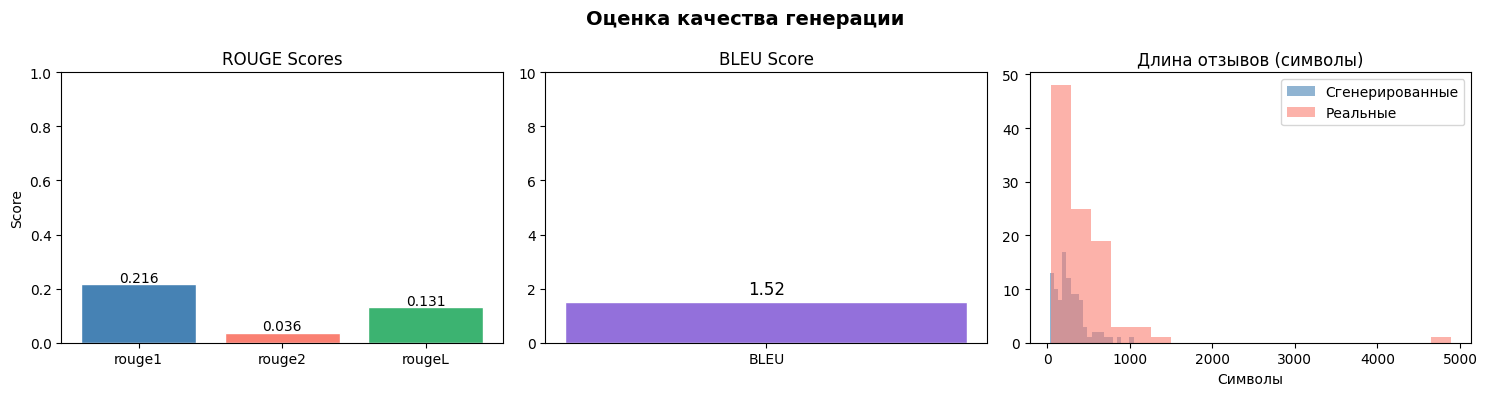

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

rouge_keys = ['rouge1', 'rouge2', 'rougeL']
rouge_vals = [rouge_result[k] for k in rouge_keys]
bars = axes[0].bar(rouge_keys, rouge_vals, color=['steelblue','salmon','mediumseagreen'], edgecolor='white')
axes[0].set_title('ROUGE Scores')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Score')
for bar, val in zip(bars, rouge_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=10)

axes[1].bar(['BLEU'], [bleu_result['score']], color='mediumpurple', edgecolor='white')
axes[1].set_title('BLEU Score')
axes[1].text(0, bleu_result['score'] + 0.3, f"{bleu_result['score']:.2f}", ha='center', fontsize=12)
axes[1].set_ylim(0, max(bleu_result['score'] * 1.5, 10))

pred_lens = [len(p) for p in predictions]
ref_lens  = [len(r) for r in references]
axes[2].hist(pred_lens, bins=20, alpha=0.6, label='Сгенерированные', color='steelblue')
axes[2].hist(ref_lens,  bins=20, alpha=0.6, label='Реальные',        color='salmon')
axes[2].set_title('Длина отзывов (символы)')
axes[2].set_xlabel('Символы')
axes[2].legend()

plt.suptitle('Оценка качества генерации', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(METADATA_DIR / 'eval_metrics.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
N_SHOW = 5

for i in range(N_SHOW):
    row = eval_df.iloc[i]
    print('')
    print(f'RATING={row["rating_int"]} | COUNTRY={row["country"]} | TOPIC={row["topic"]}')
    print('Реальный отзыв')
    print(str(row['clean_text'])[:400])
    print('Сгенерированный')
    print(predictions[i][:500])


RATING=1 | COUNTRY=GB | TOPIC=Amazon, customer service, not very good
Реальный отзыв
Absolutely fed up with items being left outside the door being stolen because I live in a block of flats and the entrance door is always left open. Got onto Amazon. I’ve got to wait two days even though my last item was definitely stolen.
Сгенерированный
Amazon, customer services, not very good. They are the worst company I have ever dealt with and they do nothing to help me or my family in any way.

RATING=3 | COUNTRY=IE | TOPIC=i cannot believe my kindle doesn't read .docs
Реальный отзыв
i cannot believe my kindle doesn't read .docs . Otherwise it is a good product.
Сгенерированный
ive never had a problem with Amazon.

RATING=1 | COUNTRY=US | TOPIC=I will stop buying from them immediately, scam
Реальный отзыв
It is a living hell now solving anything, went from a Top 5 customer service to a dump. I buy from whole foods on a regular basis and sometimes something come out spoiled or missing, i contact 

In [ ]:
print('ДОСТУПНЫЕ ЗНАЧЕНИЯ')
print(f'\nРейтинг: от {metadata["rating_range"][0]} до {metadata["rating_range"][1]}')
print(f'\nСтраны ({len(metadata["unique_countries"])} шт.):')
print(', '.join(metadata['unique_countries']))
print(f'\nПервые 30 тем:')
for i, t in enumerate(metadata['unique_topics'][:30]):
    print(f'  {i+1:2d}. {t}')

ДОСТУПНЫЕ ЗНАЧЕНИЯ

Рейтинг: от 1 до 5

Страны (144 шт.):
AD, AE, AF, AG, AM, AR, AT, AU, AZ, BA, BB, BD, BE, BG, BH, BM, BO, BQ, BR, BS, BW, BY, BZ, CA, CD, CH, CI, CL, CM, CN, CO, CR, CW, CY, CZ, DE, DK, DO, DZ, EC, EE, EG, ES, ET, FI, FJ, FR, GB, GE, GF, GG, GH, GI, GR, GT, GY, HK, HN, HR, HU, ID, IE, IL, IM, IN, IQ, IR, IS, IT, JE, JM, JO, JP, KE, KG, KR, KW, KZ, LA, LB, LK, LT, LU, LV, MA, MC, MD, ME, MG, MM, MO, MQ, MT, MU, MV, MX, MY, NG, NI, NL, NO, NP, NZ, OM, PA, PE, PG, PH, PK, PL, PR, PT, PY, QA, RO, RS, RU, RW, SA, SE, SG, SI, SK, SL, SO, SR, SV, TH, TN, TR, TT, TW, TZ, UA, UG, US, UY, Unknown, VE, VG, VI, VN, ZA, ZM

Первые 30 тем:
   1. !!AVOID!!
   2. !Exceptional values & integrity!
   3. " Amazon made Shopping an enjoyable Hobby"
   4. " DO NOT TRUST THEIR SO CALLED GET IT BY DATES!
   5. " Parcel handed to resident " NO AMAZON , NOBODY WAS HOME
   6. "AMAZING" AMAZON
   7. "Amazon does not honour its advertised…
   8. "Amazon has truly revolutionized the…
   9. "Amaz

In [ ]:
MY_RATING  = 1
MY_COUNTRY = 'GB'
MY_TOPIC   = 'Delivery issues'

review = generate_review(
    rating    = MY_RATING,
    country   = MY_COUNTRY,
    topic     = MY_TOPIC,
    model     = model,
    tokenizer = tokenizer,
    gen_cfg   = gen_cfg,
    device    = DEVICE
)

print(f'Параметры')
print(f'Рейтинг: {MY_RATING} / 5')
print(f'Страна:  {MY_COUNTRY}')
print(f'Тема:    {MY_TOPIC}')
print('Сгенерированный отзыв:')
print()
print(review)

Параметры
Рейтинг: 1 / 5
Страна:  GB
Тема:    Delivery issues
Сгенерированный отзыв:

Delivery issues, delivery drivers don’t care what they say. They just leave you on the phone to complain about it and then tell you that is because of their incompetence!


In [ ]:
N_VARIANTS = 3

print(f'Генерируем {N_VARIANTS} варианта для:')
print(f'  RATING={MY_RATING} | COUNTRY={MY_COUNTRY} | TOPIC={MY_TOPIC}')

for i in range(N_VARIANTS):
    print(f'\nВариант {i+1}')
    cfg_variant = gen_cfg.copy()
    cfg_variant['temperature'] = 0.7 + i * 0.15

    r = generate_review(
        rating    = MY_RATING,
        country   = MY_COUNTRY,
        topic     = MY_TOPIC,
        model     = model,
        tokenizer = tokenizer,
        gen_cfg   = cfg_variant,
        device    = DEVICE
    )
    print(r)

Генерируем 3 варианта для:
  RATING=1 | COUNTRY=GB | TOPIC=Delivery issues

Вариант 1
Delivery issues, and customer service are horrible.I ordered an item on Amazon for £300 with a return label that stated it would be delivered the next day when I tried to contact them - they didn't even respond as promised! The courier had no idea what was going down so he went in circles over this issue without any explanation or assistance. They could only get me through email if my parcel arrived damaged before Christmas (which is how you treat your customers) but then got into trouble again after trying to call back via chat & finally received confirmation of delivery!!

Вариант 2
Delivery issues, with no delivery details provided. No attempt to fix the issue myself. Amazon have had a very poor service for years and I now know that they are not just ripping up my parcels or sending them elsewhere!I contacted customer services about this at 1pm on Wednesday which is still in progress but it seems a

In [ ]:
def search_topics(keyword: str, top_n: int = 20) -> list:
    kw = keyword.lower()
    matches = [t for t in metadata['unique_topics'] if kw in t.lower()]
    return matches[:top_n]


keyword = 'delivery'
results = search_topics(keyword)
print(f'Темы со словом "{keyword}" ({len(results)} шт.):')
for i, t in enumerate(results, 1):
    print(f'  {i:2d}. {t}')

Темы со словом "delivery" (20 шт.):
   1. "Qualtex Ltd" delivery service
   2. "Ran into an issue when attempting your delivery"!!!
   3. 1 Amazon delivery dates and no help from Amazon
   4. 1 star on deliverys at the moment...
   5. 2 day delivery is false advertising
   6. 2 days late on a fresh delivery no…
   7. 2 weeks of delivery hell!!
   8. 3 1/2 weeks. Still no delivery
   9. 3 days of delivery time is fine
  10. 30th+ time that my delivery wasn't
  11. A Review of Amazon’s Delivery Performance
  12. A company I have found I can trust for speedy delivery.
  13. A delivery company that can't deliver?
  14. A signed for delivery that wasn’t delivered!
  15. A very,very,very bad delivery
  16. ALways fast delivery and any issues I…
  17. AMAZON A ONE STOP SHOP & Wait for the delivery man, Love it.
  18. AMAZON DELIVERY DRIVERS HERE SUCK!!
  19. AMAZON DELIVERY IS TRULY APPALLING
  20. AMAZON DELIVERY TO YOUR DOOR IS A JOKE!


In [ ]:
chosen_topic = results[0] if results else 'General'
print(f'Используем тему: "{chosen_topic}"\n')

generated = generate_review(
    rating    = 1,
    country   = 'GB',
    topic     = chosen_topic,
    model     = model,
    tokenizer = tokenizer,
    gen_cfg   = gen_cfg,
    device    = DEVICE
)
print(generated)

Используем тему: ""Qualtex Ltd" delivery service"

Qualify LLC delivery service. I have been waiting for a package from Amazon since the beginning of this year and they are refusing to deliver it as promised but now my parcel is delayed in transit so no one can find me or even get out!


In [ ]:
custom_cfg = {
    'max_new_tokens':       150,
    'do_sample':            True,
    'temperature':          0.3,
    'top_p':                0.90,
    'top_k':                40,
    'repetition_penalty':   1.4,
    'no_repeat_ngram_size': 3,
}

result = generate_review(
    rating  = 5,
    country = 'US',
    topic   = 'Amazing experience',
    gen_cfg = custom_cfg,
    model     = model,
    tokenizer = tokenizer,
    device    = DEVICE
)
print(result)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Amazing! I have ordered many items from Amazon but lately, they’ve all been very disappointing. The last time someone sent me a product was because it wasn't shipped and that the item would not ship to my address on another location like this one at Wal-Mart (which is where everything else came in). This has happened quite often now with other stores than here for example; when you order something which might be too expensive or inconvenient/stuck together over an hour of work


In [ ]:
print('ИТОГОВЫЙ ОТЧЕТ')
print(f'Модель: дистилированная GPT-2')
print(f'Тестовых примеров: {N_EVAL:<33}')
print(f'Perplexity: {ppl:<35.2f}')
print(f'BLEU: {bleu_result["score"]:<35.2f}')
print(f'ROUGE-1: {rouge_result["rouge1"]:<35.4f}')
print(f'ROUGE-2: {rouge_result["rouge2"]:<35.4f}')
print(f'ROUGE-L: {rouge_result["rougeL"]:<35.4f}')


ИТОГОВЫЙ ОТЧЕТ
Модель: дистилированная GPT-2
Тестовых примеров: 100                              
Perplexity: 18.47                              
BLEU: 1.52                               
ROUGE-1: 0.2156                             
ROUGE-2: 0.0363                             
ROUGE-L: 0.1313                             
